# PyTorch FNN Regression — 은닉층 노드 수 비교

이 노트북은 모든 은닉층의 노드 수를 동일하게 유지한 채 **8 → 1**로 줄여가며 FNN 회귀 성능과 모델 복잡도를 비교합니다. 각 노드 수는 서로 다른 초기값으로 **6회 반복**합니다.

- 입력: `data1`
- 출력: `data2`
- 은닉층 수: 3개로 고정
- 은닉층 너비: `8, 7, 6, ..., 1`
- 반복 횟수: 노드 수마다 6회, 모든 노드 수에 동일한 6개 seed 적용
- 기본 평가: 고정된 80:20 holdout 분할의 Test RMSE
- 요청 플롯: x축=노드 수, 왼쪽 y축=6회 Test RMSE 박스플롯, 오른쪽 y축=학습 가능한 파라미터 수
- 모델 저장: `fnn_model_node_8-1.pt`, ..., `fnn_model_node_1-6.pt` 형식으로 총 48개

각 `.pt` 체크포인트에는 모델 가중치뿐 아니라 구조, 스케일러 통계, RMSE도 함께 저장됩니다. 모델을 고를 때는 6회 Test RMSE 중앙값이 낮은 구조를 우선 확인하세요.


In [1]:
# 1. 라이브러리 및 데이터 저장소 준비

import os
import random
import copy
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Colab에서는 저장소를 복제하고, 로컬에서는 현재 작업 폴더(./)를 사용합니다.
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    REPO_ROOT = '/content/Basic_example_copy'
    if not os.path.exists(REPO_ROOT):
        subprocess.run(
            [
                'git', 'clone', '-q',
                'https://github.com/Jaehoon-Shim/Basic_example.git',
                REPO_ROOT,
            ],
            check=True,
        )
else:
    REPO_ROOT = os.path.abspath('.')

os.makedirs(os.path.join(REPO_ROOT, 'data'), exist_ok=True)
os.makedirs(os.path.join(REPO_ROOT, 'results'), exist_ok=True)

print('Environment:', 'Google Colab' if IN_COLAB else 'Local Jupyter')
print('Current work:', os.getcwd())
print('Repository :', REPO_ROOT)


Environment: Local Jupyter
Current work: c:\Users\HP\Documents\Github\Basic_example
Repository : c:\Users\HP\Documents\Github\Basic_example


In [2]:
# 2. 실험 설정

SEED = 42
EPOCHS = 1000
LEARNING_RATE = 1e-3
PRINT_INTERVAL = 500

# 모든 은닉층은 같은 너비를 사용하며, 은닉층 개수는 기존과 동일한 3개입니다.
HIDDEN_NODE_OPTIONS = list(range(8, 0, -1))
N_HIDDEN_LAYERS = 3
N_REPEATS = 6

# 모델 선택을 위한 기본 설정: 모든 모델에 똑같은 80:20 분할을 적용합니다.
USE_HOLDOUT_SPLIT = True
TEST_SIZE = 0.20

BASE_DIR = REPO_ROOT
RESULT_DIR = os.path.join(BASE_DIR, 'results', 'node_sweep')
MODEL_DIR = os.path.join(RESULT_DIR, 'models_6runs')
CSV_PATH = os.path.join(BASE_DIR, 'data', 'test.csv')

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

set_global_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device       :', DEVICE)
print('CSV Path     :', CSV_PATH)
print('Result Dir   :', RESULT_DIR)
print('Node options :', HIDDEN_NODE_OPTIONS)
print('Hidden layers:', N_HIDDEN_LAYERS)
print('Repeats/node :', N_REPEATS)
print('Total models :', len(HIDDEN_NODE_OPTIONS) * N_REPEATS)
print('CSV Exists   :', os.path.exists(CSV_PATH))


Device       : cpu
CSV Path     : c:\Users\HP\Documents\Github\Basic_example\data\test.csv
Result Dir   : c:\Users\HP\Documents\Github\Basic_example\results\node_sweep
Node options : [8, 7, 6, 5, 4, 3, 2, 1]
Hidden layers: 3
Repeats/node : 6
Total models : 48
CSV Exists   : True


In [3]:
# 3. CSV 로드 및 전처리

df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]

required_columns = ['data1', 'data2']
if not all(col in df.columns for col in required_columns):
    raise ValueError(
        f'CSV에 {required_columns} 열이 필요합니다. '
        f'현재 열: {df.columns.tolist()}'
    )

df = df[required_columns].copy()
df['data1'] = pd.to_numeric(df['data1'], errors='coerce')
df['data2'] = pd.to_numeric(df['data2'], errors='coerce')
df = df.dropna().reset_index(drop=True)

print('Data shape:', df.shape)
display(df.head())
display(df.describe())


Data shape: (400, 2)


,data1,data2
0,0.000000,7.438766
1,0.100251,7.311275
2,0.200501,7.496599
3,0.300752,7.701600
4,0.401003,7.327267


,data1,data2
count,400.000000,400.000000
mean,20.000000,5.441844
std,11.590406,3.665019
min,0.000000,0.200000
25%,10.000000,2.509633
50%,20.000000,4.464003
75%,30.000000,7.972711
max,40.000000,16.573641


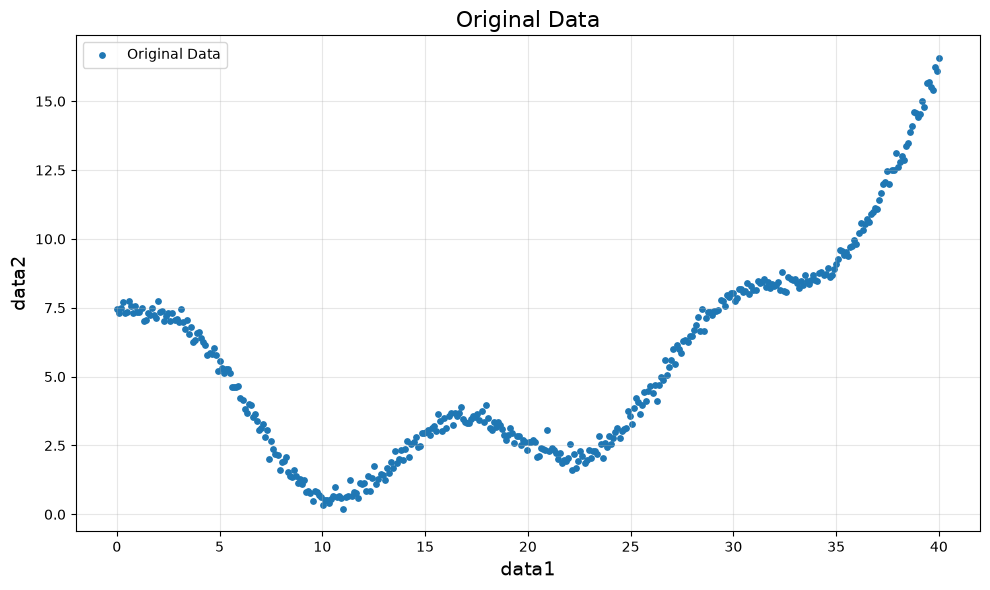

Saved: c:\Users\HP\Documents\Github\Basic_example\results\node_sweep\original_data.jpg


In [4]:
# 4. 원본 데이터 확인

plt.figure(figsize=(10, 6))
plt.scatter(df['data1'], df['data2'], s=15, label='Original Data')
plt.xlabel('data1', fontsize=14)
plt.ylabel('data2', fontsize=14)
plt.title('Original Data', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

original_data_path = os.path.join(RESULT_DIR, 'original_data.jpg')
plt.savefig(original_data_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', original_data_path)


In [5]:
# 5. 모든 모델에 공통으로 사용할 Train/Test 분할과 표준화

X = df[['data1']].to_numpy(dtype=np.float32)
y = df[['data2']].to_numpy(dtype=np.float32)

if USE_HOLDOUT_SPLIT:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=SEED,
        shuffle=True,
    )
else:
    # 기존 노트북처럼 동일 데이터를 평가하려면 USE_HOLDOUT_SPLIT=False로 바꾸세요.
    X_train, y_train = X.copy(), y.copy()
    X_test, y_test = X.copy(), y.copy()

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)
X_test_scaled = x_scaler.transform(X_test).astype(np.float32)
y_test_scaled = y_scaler.transform(y_test).astype(np.float32)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32, device=DEVICE)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32, device=DEVICE)

print('X_train:', X_train_tensor.shape)
print('X_test :', X_test_tensor.shape)
print('Split  :', '80:20 holdout' if USE_HOLDOUT_SPLIT else 'Train = Test')


X_train: torch.Size([320, 1])
X_test : torch.Size([80, 1])
Split  : 80:20 holdout


In [6]:
# 6. 노드 수를 인자로 받는 FNN 모델과 평가 함수

class FNNRegressor(nn.Module):
    def __init__(
        self,
        hidden_nodes,
        hidden_layers=N_HIDDEN_LAYERS,
        input_dim=1,
        output_dim=1,
    ):
        super().__init__()

        layers = [nn.Linear(input_dim, hidden_nodes), nn.ReLU()]
        for _ in range(hidden_layers - 1):
            layers.extend([
                nn.Linear(hidden_nodes, hidden_nodes),
                nn.ReLU(),
            ])
        layers.append(nn.Linear(hidden_nodes, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def regression_rmse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


for nodes in HIDDEN_NODE_OPTIONS:
    sample_model = FNNRegressor(nodes)
    print(
        f'nodes={nodes}: '
        f'{count_trainable_parameters(sample_model):,} trainable parameters'
    )


nodes=8: 169 trainable parameters
nodes=7: 134 trainable parameters
nodes=6: 103 trainable parameters
nodes=5: 76 trainable parameters
nodes=4: 53 trainable parameters
nodes=3: 34 trainable parameters
nodes=2: 19 trainable parameters
nodes=1: 8 trainable parameters


In [7]:
# 7. 한 가지 노드 수와 반복 번호를 학습하고 체크포인트를 저장하는 함수

def train_and_save_model(hidden_nodes, run_number, run_seed):
    # 같은 run_number는 모든 노드 수에서 같은 seed를 사용합니다.
    set_global_seed(run_seed)

    model = FNNRegressor(
        hidden_nodes=hidden_nodes,
        hidden_layers=N_HIDDEN_LAYERS,
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=100,
    )

    train_loss_history = []
    test_loss_history = []
    best_test_loss = float('inf')
    best_epoch = 0
    best_model_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        optimizer.zero_grad()

        train_pred = model(X_train_tensor)
        train_loss = criterion(train_pred, y_train_tensor)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(X_test_tensor)
            test_loss = criterion(test_pred, y_test_tensor)

        train_loss_value = float(train_loss.item())
        test_loss_value = float(test_loss.item())
        train_loss_history.append(train_loss_value)
        test_loss_history.append(test_loss_value)
        scheduler.step(test_loss_value)

        if test_loss_value < best_test_loss:
            best_test_loss = test_loss_value
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % PRINT_INTERVAL == 0 or epoch == EPOCHS:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f'[nodes={hidden_nodes}, run={run_number}] {epoch:4d}/{EPOCHS} | '
                f'Train={train_loss_value:.8f} | '
                f'Test={test_loss_value:.8f} | '
                f'LR={current_lr:.6g}'
            )

    model.load_state_dict(best_model_state)
    model.eval()

    with torch.no_grad():
        train_pred_scaled = model(X_train_tensor).cpu().numpy()
        test_pred_scaled = model(X_test_tensor).cpu().numpy()

    train_pred = y_scaler.inverse_transform(train_pred_scaled)
    test_pred = y_scaler.inverse_transform(test_pred_scaled)
    train_rmse = regression_rmse(y_train, train_pred)
    test_rmse = regression_rmse(y_test, test_pred)
    parameter_count = count_trainable_parameters(model)

    model_filename = f'fnn_model_node_{hidden_nodes}-{run_number}.pt'
    model_path = os.path.join(MODEL_DIR, model_filename)

    checkpoint = {
        'model_state_dict': {
            name: tensor.detach().cpu()
            for name, tensor in model.state_dict().items()
        },
        'hidden_nodes': int(hidden_nodes),
        'hidden_layers': int(N_HIDDEN_LAYERS),
        'run_number': int(run_number),
        'run_seed': int(run_seed),
        'input_dim': 1,
        'output_dim': 1,
        'parameter_count': int(parameter_count),
        'best_epoch': int(best_epoch),
        'best_test_loss_scaled': float(best_test_loss),
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'x_scaler': {
            'mean': x_scaler.mean_.astype(np.float32).tolist(),
            'scale': x_scaler.scale_.astype(np.float32).tolist(),
            'var': x_scaler.var_.astype(np.float32).tolist(),
        },
        'y_scaler': {
            'mean': y_scaler.mean_.astype(np.float32).tolist(),
            'scale': y_scaler.scale_.astype(np.float32).tolist(),
            'var': y_scaler.var_.astype(np.float32).tolist(),
        },
        'base_seed': int(SEED),
        'epochs': int(EPOCHS),
        'learning_rate': float(LEARNING_RATE),
        'use_holdout_split': bool(USE_HOLDOUT_SPLIT),
        'test_size': float(TEST_SIZE),
    }
    torch.save(checkpoint, model_path)

    history = pd.DataFrame({
        'hidden_nodes': hidden_nodes,
        'run_number': run_number,
        'run_seed': run_seed,
        'epoch': np.arange(1, EPOCHS + 1),
        'train_loss_scaled': train_loss_history,
        'test_loss_scaled': test_loss_history,
    })

    result = {
        'hidden_nodes': hidden_nodes,
        'hidden_layers': N_HIDDEN_LAYERS,
        'run_number': run_number,
        'run_seed': run_seed,
        'parameter_count': parameter_count,
        'best_epoch': best_epoch,
        'best_test_loss_scaled': best_test_loss,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'model_filename': model_filename,
        'model_path': model_path,
    }

    print(
        f'Saved {model_filename} | seed={run_seed} | params={parameter_count:,} | '
        f'Test RMSE={test_rmse:.6f}'
    )
    return result, history


In [8]:
# 8. 노드 수 8 → 1 × 6회 전체 실험 실행 및 모델 저장

all_results = []
all_histories = []

for hidden_nodes in HIDDEN_NODE_OPTIONS:
    for run_number in range(1, N_REPEATS + 1):
        run_seed = SEED + run_number - 1

        print('\n' + '=' * 72)
        print(
            f'Training: {hidden_nodes} nodes in every hidden layer | '
            f'run {run_number}/{N_REPEATS} | seed={run_seed}'
        )
        print('=' * 72)

        result, history = train_and_save_model(
            hidden_nodes=hidden_nodes,
            run_number=run_number,
            run_seed=run_seed,
        )
        all_results.append(result)
        all_histories.append(history)

comparison_df = pd.DataFrame(all_results).sort_values(
    ['hidden_nodes', 'run_number'], ascending=[False, True]
).reset_index(drop=True)
history_df = pd.concat(all_histories, ignore_index=True)

summary_df = (
    comparison_df
    .groupby('hidden_nodes', as_index=False)
    .agg(
        parameter_count=('parameter_count', 'first'),
        runs=('run_number', 'count'),
        test_rmse_mean=('test_rmse', 'mean'),
        test_rmse_median=('test_rmse', 'median'),
        test_rmse_std=('test_rmse', 'std'),
        test_rmse_min=('test_rmse', 'min'),
        test_rmse_max=('test_rmse', 'max'),
    )
    .sort_values('hidden_nodes', ascending=False)
    .reset_index(drop=True)
)

comparison_csv_path = os.path.join(RESULT_DIR, 'node_width_comparison_6runs.csv')
summary_csv_path = os.path.join(RESULT_DIR, 'node_width_summary_6runs.csv')
history_csv_path = os.path.join(RESULT_DIR, 'node_width_training_history_6runs.csv')

comparison_df.to_csv(comparison_csv_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)
history_df.to_csv(history_csv_path, index=False)

print('\nSaved:', comparison_csv_path)
print('Saved:', summary_csv_path)
print('Saved:', history_csv_path)
saved_model_count = len([
    name for name in os.listdir(MODEL_DIR)
    if name.startswith('fnn_model_node_') and name.endswith('.pt')
])
print('Saved model count:', saved_model_count)
print('Expected model count:', len(HIDDEN_NODE_OPTIONS) * N_REPEATS)



Training: 8 nodes in every hidden layer | run 1/6 | seed=42
[nodes=8, run=1]    1/1000 | Train=0.96777850 | Test=1.30057526 | LR=0.001
[nodes=8, run=1]  500/1000 | Train=0.05868971 | Test=0.06077795 | LR=0.001
[nodes=8, run=1] 1000/1000 | Train=0.01755112 | Test=0.01350104 | LR=0.001
Saved fnn_model_node_8-1.pt | seed=42 | params=169 | Test RMSE=0.410935

Training: 8 nodes in every hidden layer | run 2/6 | seed=43
[nodes=8, run=2]    1/1000 | Train=1.12802958 | Test=1.54058146 | LR=0.001
[nodes=8, run=2]  500/1000 | Train=0.07806784 | Test=0.08658517 | LR=0.001
[nodes=8, run=2] 1000/1000 | Train=0.05032388 | Test=0.05075999 | LR=0.001
Saved fnn_model_node_8-2.pt | seed=43 | params=169 | Test RMSE=0.796802

Training: 8 nodes in every hidden layer | run 3/6 | seed=44
[nodes=8, run=3]    1/1000 | Train=1.05374694 | Test=1.33991623 | LR=0.001
[nodes=8, run=3]  500/1000 | Train=0.05319867 | Test=0.05414633 | LR=0.001
[nodes=8, run=3] 1000/1000 | Train=0.04204909 | Test=0.04115222 | LR=0.00

In [9]:
# 9. 6회 반복 성능 요약표와 추천 모델

display(
    summary_df
    .sort_values(['test_rmse_median', 'parameter_count'])
    .style.format({
        'test_rmse_mean': '{:.6f}',
        'test_rmse_median': '{:.6f}',
        'test_rmse_std': '{:.6f}',
        'test_rmse_min': '{:.6f}',
        'test_rmse_max': '{:.6f}',
    })
)

# 먼저 6회 RMSE 중앙값이 가장 낮은 노드 수를 고릅니다.
best_width_row = summary_df.sort_values(
    ['test_rmse_median', 'parameter_count'],
    ascending=[True, True],
).iloc[0]
BEST_HIDDEN_NODES = int(best_width_row['hidden_nodes'])

# 선택된 노드 수 안에서 가장 좋은 개별 체크포인트를 고릅니다.
best_row = comparison_df.loc[
    comparison_df['hidden_nodes'] == BEST_HIDDEN_NODES
].sort_values('test_rmse').iloc[0]

BEST_MODEL_PATH = best_row['model_path']

print('Recommended width (based on median of 6 runs)')
print('  hidden nodes :', BEST_HIDDEN_NODES)
print('  median RMSE  :', f'{best_width_row["test_rmse_median"]:.8f}')
print('  RMSE std     :', f'{best_width_row["test_rmse_std"]:.8f}')
print()
print('Best saved checkpoint within the recommended width')
print('  hidden nodes :', int(best_row['hidden_nodes']))
print('  run number   :', int(best_row['run_number']))
print('  run seed     :', int(best_row['run_seed']))
print('  parameters   :', int(best_row['parameter_count']))
print('  Test RMSE    :', f'{best_row["test_rmse"]:.8f}')
print('  checkpoint   :', BEST_MODEL_PATH)


,hidden_nodes,parameter_count,runs,test_rmse_mean,test_rmse_median,test_rmse_std,test_rmse_min,test_rmse_max
0,8,169,6,0.581762,0.564188,0.218321,0.347250,0.818834
1,7,134,6,1.285768,0.739882,1.389819,0.563589,4.110162
2,6,103,6,1.331724,0.745868,1.372527,0.677547,4.120716
3,5,76,6,1.123000,0.981640,0.403748,0.790363,1.884455
4,4,53,6,2.503292,1.990665,1.309848,0.920258,4.110307
6,2,19,6,2.713112,2.150778,1.096515,1.820135,4.124730
5,3,34,6,2.652768,2.211722,1.180559,1.621818,4.123439
7,1,8,6,4.062037,4.128436,0.238230,3.584106,4.214943


Recommended width (based on median of 6 runs)
  hidden nodes : 8
  median RMSE  : 0.56418798
  RMSE std     : 0.21832065

Best saved checkpoint within the recommended width
  hidden nodes : 8
  run number   : 4
  run seed     : 45
  parameters   : 169
  Test RMSE    : 0.34724989
  checkpoint   : c:\Users\HP\Documents\Github\Basic_example\results\node_sweep\models_6runs\fnn_model_node_8-4.pt


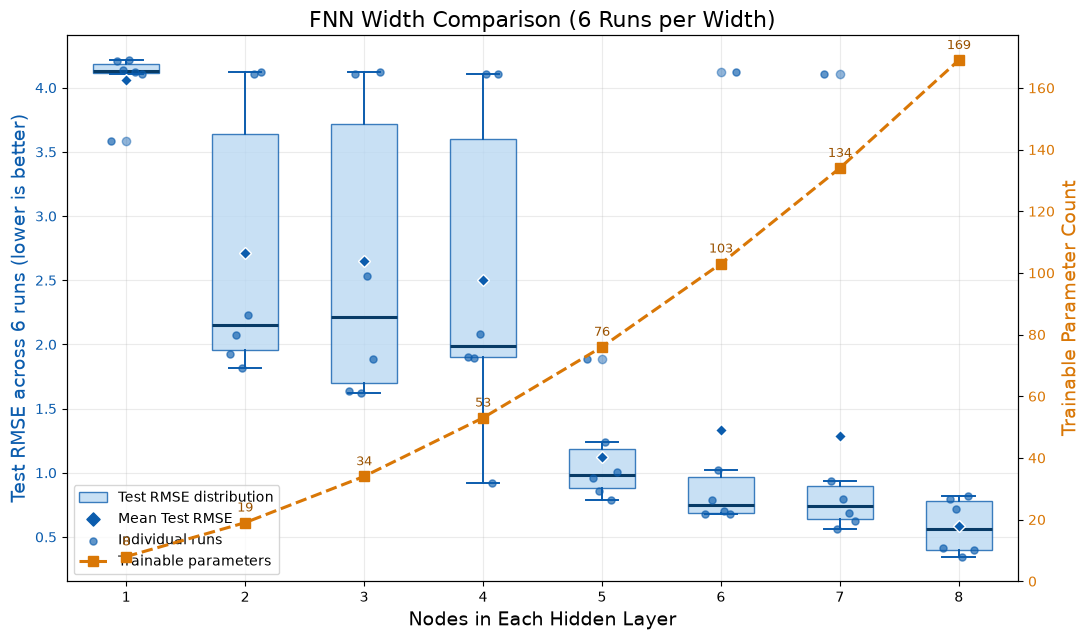

Saved: c:\Users\HP\Documents\Github\Basic_example\results\node_sweep\node_width_RMSE_boxplot_vs_parameters_6runs.png


In [10]:
# 10. 요청 플롯: x=노드 수, y=6회 Test RMSE 박스플롯, y2=파라미터 수

x_nodes = np.array(sorted(HIDDEN_NODE_OPTIONS))
boxplot_rmse = [
    comparison_df.loc[
        comparison_df['hidden_nodes'] == nodes,
        'test_rmse',
    ].to_numpy()
    for nodes in x_nodes
]
parameter_by_node = (
    summary_df.set_index('hidden_nodes')
    .loc[x_nodes, 'parameter_count']
    .to_numpy()
)

fig, ax1 = plt.subplots(figsize=(11, 6.5))

box = ax1.boxplot(
    boxplot_rmse,
    positions=x_nodes,
    widths=0.55,
    patch_artist=True,
    showmeans=True,
    meanprops={
        'marker': 'D',
        'markerfacecolor': '#0B5CAD',
        'markeredgecolor': 'white',
        'markersize': 6,
    },
    medianprops={'color': '#083B66', 'linewidth': 2.2},
    whiskerprops={'color': '#0B5CAD', 'linewidth': 1.4},
    capprops={'color': '#0B5CAD', 'linewidth': 1.4},
    flierprops={
        'marker': 'o',
        'markerfacecolor': '#0B5CAD',
        'markeredgecolor': '#0B5CAD',
        'alpha': 0.45,
    },
)
for patch in box['boxes']:
    patch.set_facecolor('#B9D8F2')
    patch.set_edgecolor('#0B5CAD')
    patch.set_alpha(0.78)

# 6개 개별 실행값도 함께 표시합니다.
for nodes, values in zip(x_nodes, boxplot_rmse):
    jitter = np.linspace(-0.13, 0.13, len(values))
    ax1.scatter(
        np.full(len(values), nodes) + jitter,
        values,
        color='#0B5CAD',
        s=26,
        alpha=0.65,
        zorder=3,
    )
run_handle = ax1.scatter(
    [], [], color='#0B5CAD', s=26, alpha=0.65, label='Individual runs'
)

ax1.set_xlabel('Nodes in Each Hidden Layer', fontsize=14)
ax1.set_ylabel('Test RMSE across 6 runs (lower is better)', color='#0B5CAD', fontsize=14)
ax1.tick_params(axis='y', labelcolor='#0B5CAD')
ax1.set_xticks(x_nodes)
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
parameter_line = ax2.plot(
    x_nodes,
    parameter_by_node,
    color='#D97706',
    marker='s',
    linestyle='--',
    linewidth=2.2,
    markersize=7,
    label='Trainable parameters',
)
ax2.set_ylabel('Trainable Parameter Count', color='#D97706', fontsize=14)
ax2.tick_params(axis='y', labelcolor='#D97706')

for x_value, parameter_count in zip(x_nodes, parameter_by_node):
    ax2.annotate(
        f'{int(parameter_count)}',
        (x_value, parameter_count),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        color='#9A5200',
        fontsize=9,
    )

mean_handle = ax1.scatter(
    [], [],
    marker='D',
    color='#0B5CAD',
    s=45,
    label='Mean Test RMSE',
)
ax1.legend(
    [box['boxes'][0], mean_handle, run_handle, parameter_line[0]],
    [
        'Test RMSE distribution',
        'Mean Test RMSE',
        'Individual runs',
        'Trainable parameters',
    ],
    loc='best',
)

plt.title(
    f'FNN Width Comparison ({N_REPEATS} Runs per Width)',
    fontsize=16,
)
fig.tight_layout()

comparison_plot_path = os.path.join(
    RESULT_DIR,
    'node_width_RMSE_boxplot_vs_parameters_6runs.png',
)
plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', comparison_plot_path)
